# Plotting Playground  
### Tips and Tricks for using cartopy and matplotlib for a variety of common tasks

In [1]:
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patches as mpatch
from matplotlib.tri import Triangulation
import numpy as np
import geopandas as gpd
import pandas as pd
import xarray as xr
import os, sys, cmocean, cartopy
from shapely import Polygon, LinearRing, LineString, Point
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)

### ACS domain
We rely on a custom Australian Albers projection here, as the PROJ/cartopy implementation of ESPG:9473/3577 has an upper latitude limit that is too low for the northern extent of the domain  
See https://epsg.io/3577 and https://epsg.io/9473 for information about each of these projections  
For our purposes, a projection based upon the GRS80 ellipsoid is sufficient to mimic either of these projection systems

In [3]:
aus_albers = cartopy.crs.AlbersEqualArea(
    central_longitude=132,
    standard_parallels=[-18, -36],
    globe=cartopy.crs.Globe(ellipse='GRS80')
)

# load our boundary
open_bndy = pd.read_csv('/datasets/work/oa-acs-wp3/work/SCHISM_FINAL/open_bnd/bnd_mesh/bndy_all_20231120.csv')
# create the shape using matplotlib.path - it's quicker for doing point queries
acs_mpl = mpath.Path([(lon, lat) for lon, lat in open_bndy.values])

mm = 1/25.4 # millimetres in inches

For plotting to textwidth in Word, standard margins are 2.54cm either side, leaving us approximately 15.9cm to play with. We should use this width as a starting point for all of our figures to ensure consistency, especially with regard to text sizes

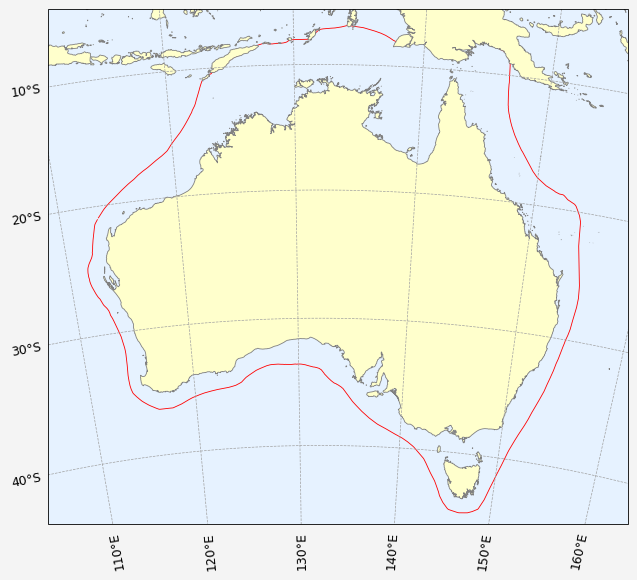

In [26]:
# I almost always specify layout=constrained, this keeps the sizing how you want it
f, ax = plt.subplots(figsize=(159*mm, 159*mm), subplot_kw=dict(projection=aus_albers), layout='constrained')
# a nice pale blue for the ocean
ax.set_facecolor('#e6f2ff')
# mpl_paths are plotted as patches - use the PathPatch routine to create this patch
ax.add_patch(mpatch.PathPatch(acs_mpl, fc='none', ec='r', transform=cartopy.crs.PlateCarree()))
# use the path extents to set the extent of the plot - note that the ymax measurement is set in the corner, so provide a buffer by adding 2 here
ax.set_extent((acs_mpl.get_extents().xmin, acs_mpl.get_extents().xmax, acs_mpl.get_extents().ymin, acs_mpl.get_extents().ymax + 2))
# gridlines
ax.gridlines(lw=0.5, ls='--', color='#a0a0a0', draw_labels=['left', 'bottom'])
# I typically use NaturalEarth for the land features, if you draw it last it will draw over the top of other plot elements
ax.add_feature(cartopy.feature.NaturalEarthFeature(category='physical', name='land', scale='10m',
                                                   facecolor='#ffffcc', edgecolor='#808080'))
# typically output to PNG at 180dpi to avoid artifacts in the final output
# f.savefig('acs_boundary.png', dpi=180)

What if you don't want your map to be a square though... we can align the boundaries of the plot to follow the graticule so that you get curved boundaries at the y margins

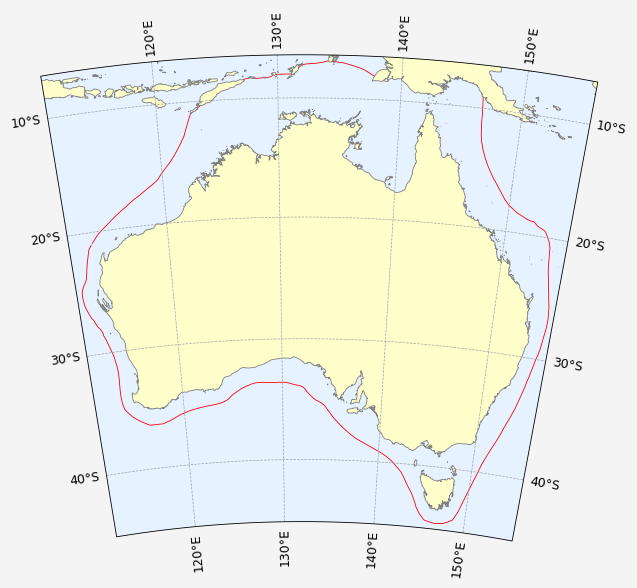

In [32]:
f, ax = plt.subplots(figsize=(159*mm, 159*mm), subplot_kw=dict(projection=aus_albers), layout='constrained')
ax.set_facecolor('#e6f2ff')
ax.add_patch(mpatch.PathPatch(acs_mpl, fc='none', ec='r', transform=cartopy.crs.PlateCarree()))

# what we want to do here is use our domain bounds to set the boundaries of the axis
# first we create the intended boundary as a path - add a padding factor to separate the boundary from the edge
pad = 0.5
rect = mpath.Path([[acs_mpl.get_extents().xmin - pad, acs_mpl.get_extents().ymin - pad], 
                   [acs_mpl.get_extents().xmin - pad, acs_mpl.get_extents().ymax + pad], 
                   [acs_mpl.get_extents().xmax + pad, acs_mpl.get_extents().ymax + pad], 
                   [acs_mpl.get_extents().xmax + pad, acs_mpl.get_extents().ymin - pad], 
                   [acs_mpl.get_extents().xmin - pad, acs_mpl.get_extents().ymin - pad]]).interpolated(100)
# now we reproject to the axis transform using ax.transData
proj_to_data = cartopy.crs.PlateCarree()._as_mpl_transform(ax) - ax.transData
# transform the path and set the boundary
rect_in_target = proj_to_data.transform_path(rect)
ax.set_boundary(rect_in_target)

# now we treat it like before, but make sure you set the pads here too
ax.set_extent((acs_mpl.get_extents().xmin - pad, acs_mpl.get_extents().xmax + pad, acs_mpl.get_extents().ymin - pad, acs_mpl.get_extents().ymax + 2))
ax.gridlines(lw=0.5, ls='--', color='#a0a0a0', draw_labels=True, ylocs=np.arange(-80, 0, 10))
ax.add_feature(cartopy.feature.NaturalEarthFeature(category='physical', name='land', scale='10m',
                                                   facecolor='#ffffcc', edgecolor='#808080'))

Note that draw_labels=True here - cartopy is inconsistent with what it wants to show if you select sides to display labels upon. I want to find a way to fix this, but it's quite difficult to manipulate cartopy artists after the fact  
For the moment, if you want to use this setup just erase the labels you don't want in inkscape or something   

## Plotting geospatial data
Nothing special here, geopandas will usually do what you want it to with the obj.plot function - just make sure the crs is set correctly  
Plotting here in Web Mercator for the fun of it

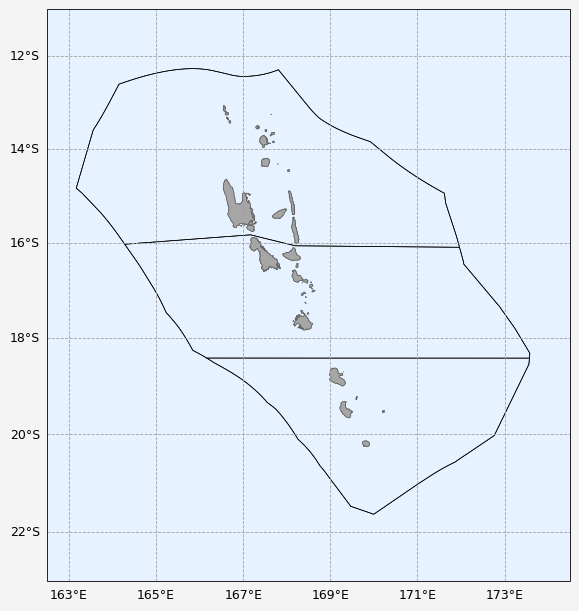

In [46]:
regions = gpd.read_file('/datasets/work/oa-vankirap/work/shapefiles/Vanuatu_subregions_areal-large.shp')
# print(regions.crs)
land = gpd.read_file('/datasets/work/oa-vankirap/work/shapefiles/Vanuatu_subregions_land-only.shp')

f, ax = plt.subplots(figsize=(159*mm, 6), subplot_kw=dict(projection=cartopy.crs.epsg(3857)), layout='constrained')
fontsize = 8
 
regions.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, transform=cartopy.crs.CRS(f'{regions.crs}'))
land.plot(ax=ax, facecolor='#a6a6a6', edgecolor='#666666', linewidth=0.5, transform=cartopy.crs.CRS(f'{land.crs}'))
ax.set_extent((162.5, 174.5, -23, -11), crs=cartopy.crs.PlateCarree())
ax.set_facecolor('#e6f2ff')
ax.gridlines(draw_labels=['left', 'bottom'], xlocs=np.arange(163, 175, 2), ylocs=np.arange(-22, -10, 2), ls='--', color='#a0a0a0', transform=cartopy.crs.PlateCarree())
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.show()

I like constructing my own Lambert Conic Conformal projections for areas such as this, which are too awkward for a UTM projection  
This close to the equator, the distortions in a Mercator projection are minimal, but it's good practice for data that might be closer to the poles

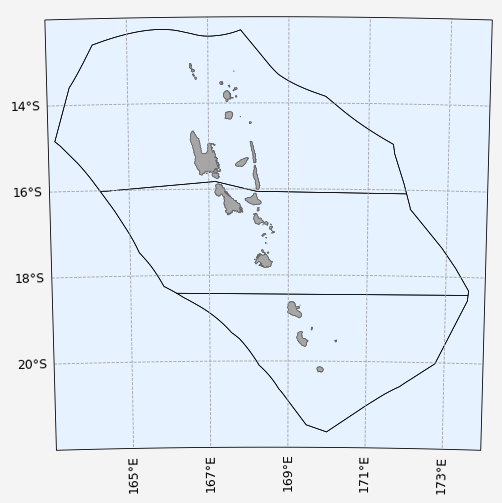

In [53]:
extent = dict(w=163, e=174, s=-22, n=-12)
lcc = cartopy.crs.LambertConformal(central_longitude=np.mean((extent['w'], extent['e'])),
                                   central_latitude=np.mean((extent['s'], extent['n'])),
                                   standard_parallels=(extent['s'] + 0.2 * (extent['n'] - extent['s']),
                                                       extent['n'] - 0.2 * (extent['n'] - extent['s'])),
                                   cutoff=0)
rect = mpath.Path([[extent['w'], extent['s']], [extent['w'], extent['n']], [extent['e'], extent['n']],
                   [extent['e'], extent['s']], [extent['w'], extent['s']]]).interpolated(500)

f, ax = plt.subplots(figsize=(159*mm, 125*mm), subplot_kw=dict(projection=lcc), layout='constrained')
fontsize = 8
 
regions.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.5, transform=cartopy.crs.CRS(f'{regions.crs}'))
land.plot(ax=ax, facecolor='#a6a6a6', edgecolor='#666666', linewidth=0.5, transform=cartopy.crs.CRS(f'{land.crs}'))

proj_to_data = cartopy.crs.PlateCarree()._as_mpl_transform(ax) - ax.transData
rect_in_target = proj_to_data.transform_path(rect)
ax.set_boundary(rect_in_target)
# note the slight padding in the north
ax.set_extent((extent['w'], extent['e'], extent['s'], extent['n'] + 0.25))
ax.set_facecolor('#e6f2ff')
ax.gridlines(draw_labels=['left', 'bottom'], x_inline=False, xlocs=np.arange(163, 175, 2), ylocs=np.arange(-22, -10, 2), ls='--', color='#a0a0a0', transform=cartopy.crs.PlateCarree())
ax.tick_params(axis='both', which='major', labelsize=fontsize)

### SCHISM plotting
These methods are likely to get eaten by `emsarray` at some stage, but here's a sample of how to go about it from first principles

In [2]:
import emsarray
a = xr.open_dataset('/datasets/work/oa-vankirap/reference/hindcast/vankirap_hindcast_201104.nc', chunks='auto')

In [6]:
type(a.ems.geometry)

/srv/envs/cmextremes/.venv/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


shapely.geometry.polygon.Polygon

In [7]:
mask = np.any((-a.depth.values[np.ravel(a.SCHISM_hgrid_face_nodes[:, :-1] - 1).astype(int)]).reshape(-1, 3) > 0, axis=1)
t = Triangulation(a.SCHISM_hgrid_node_x, a.SCHISM_hgrid_node_y, a.SCHISM_hgrid_face_nodes[:, :-1] - a.SCHISM_hgrid_face_nodes.start_index, mask=mask)

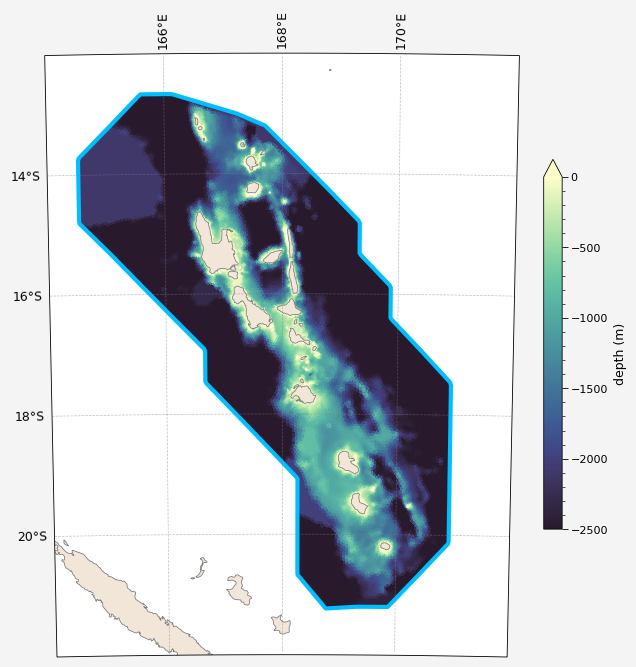

In [9]:
extent = dict(w=164, e=172, s=-22, n=-12)
lcc = cartopy.crs.LambertConformal(central_longitude=np.mean((extent['w'], extent['e'])),
                                   central_latitude=np.mean((extent['s'], extent['n'])),
                                   standard_parallels=(extent['s'] + 0.2 * (extent['n'] - extent['s']),
                                                       extent['n'] - 0.2 * (extent['n'] - extent['s'])),
                                   cutoff=0)
f, ax = plt.subplots(figsize=(159*mm, 190*mm), subplot_kw=dict(projection=lcc), layout='constrained')
cmap = cmocean.cm.deep_r.copy()
cmap.set_bad('#808080')
im = ax.tripcolor(t, -a.depth, cmap=cmap, vmax=0, transform=cartopy.crs.PlateCarree())
rect = mpath.Path([[extent['w'], extent['s']], [extent['w'], extent['n']], [extent['e'], extent['n']],
                   [extent['e'], extent['s']], [extent['w'], extent['s']]]).interpolated(500)

proj_to_data = cartopy.crs.PlateCarree()._as_mpl_transform(ax) - ax.transData
rect_in_target = proj_to_data.transform_path(rect)
ax.set_boundary(rect_in_target)
ax.set_extent((extent['w'], extent['e'], extent['s'], extent['n'] + 0.4))

ax.add_feature(cartopy.feature.NaturalEarthFeature(category='physical', name='land', scale='10m',
                                                   facecolor='#f2e6d9', edgecolor='#808080'))
ax.add_geometries(a.ems.geometry, fc='none', ec='#00bfff', lw=3, crs=cartopy.crs.PlateCarree())
lon_grid = np.arange(-180, 180, 2)
lat_grid = np.arange(-84, -0, 2)
gl = ax.gridlines(crs=cartopy.crs.PlateCarree(), draw_labels=True, x_inline=False, xlocs=lon_grid, ylocs=lat_grid,
                      linewidth=0.5, alpha=0.5, linestyle='--', color='gray')
gl.bottom_labels = False
gl.right_labels = False
ax.tick_params(labelsize=16)
cb = f.colorbar(im, ax=ax, shrink=0.5, location='right', extend='max', label='depth (m)')
cb.ax.tick_params(labelsize=8)
cb.ax.set_yticks(np.arange(-2500, 500, 500))

If we're just after the mesh, and you want a nice background, GEBCO can be the way to go

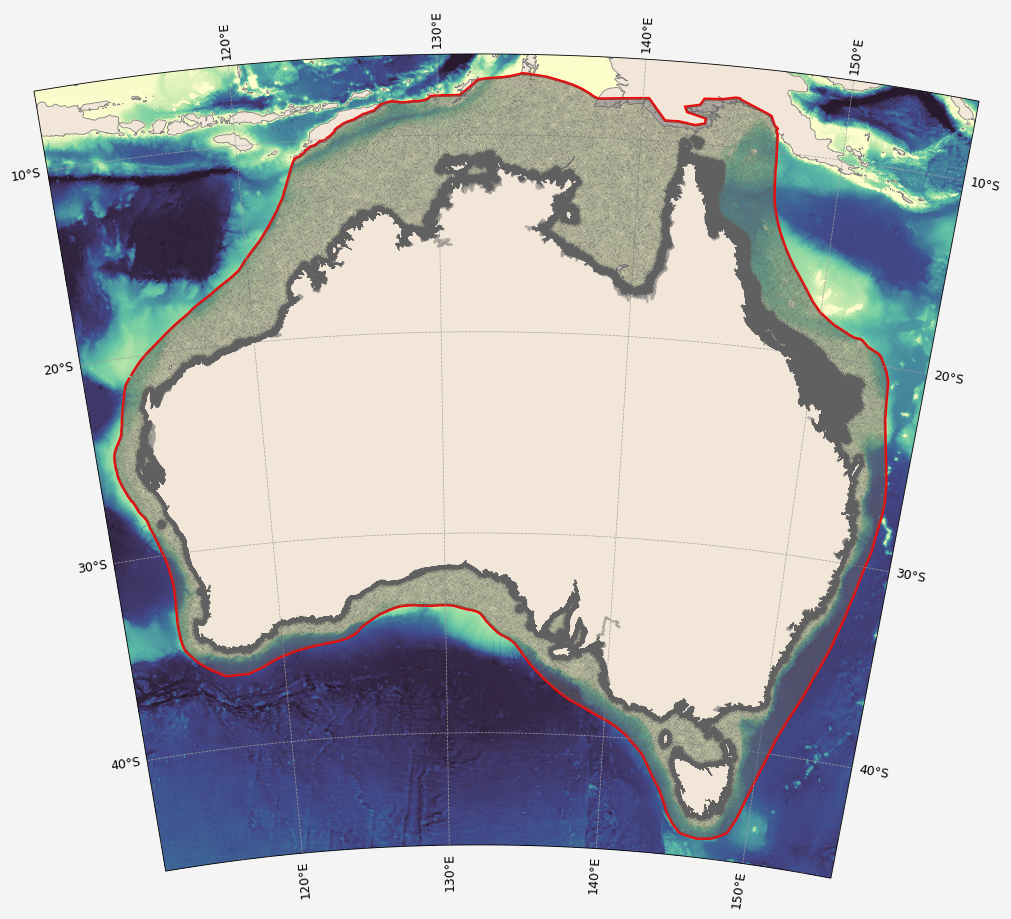

In [4]:
schism_mesh = xr.open_dataset('/datasets/work/oa-acs-wp3/work/SCHISM_FINAL/test_meshes/outputs/schout_tide_atmos.nc', chunks='auto')
# doing the trimmed aus_albers figure setup here, the traingulation works quicker if defined in the xy space
xyz = aus_albers.transform_points(cartopy.crs.PlateCarree(), schism_mesh.SCHISM_hgrid_node_x, schism_mesh.SCHISM_hgrid_node_y)
x = xyz[:, 0]
y = xyz[:, 1]
schism_t = Triangulation(x, y, schism_mesh.SCHISM_hgrid_face_nodes[:, :-1] - schism_mesh.SCHISM_hgrid_face_nodes.start_index)

# pad the figure by a degree on all sides, just for nice spacing
pad = 1
minx, maxx, miny, maxy = (acs_mpl.get_extents().xmin - pad, acs_mpl.get_extents().xmax + pad, 
                          acs_mpl.get_extents().ymin - pad, acs_mpl.get_extents().ymax + pad)

# load GEBCO, and clip out the section we want in our plot
# given how zoomed out we will be, slicing for every 10th value is sufficient
# this keeps the quadmesh from taking too long to render
bathy_data = xr.open_dataset('/datasets/work/oa-sle/reference/Bathy/GEBCO_2023/GEBCO_2023.nc')
bathy_trim = bathy_data.where((bathy_data['lat'] > miny) & (bathy_data['lat'] < maxy) &
                              (bathy_data['lon'] > minx) & (bathy_data['lon'] < maxx), 
                              drop=True)['elevation'][::10, ::10]

f, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection=aus_albers), layout='constrained')
ax.set_facecolor('#e6f2ff')
ax.add_patch(mpatch.PathPatch(acs_mpl, fc='none', ec='r', lw=2, zorder=2, transform=cartopy.crs.PlateCarree()))

# what we want to do here is use our domain bounds to set the boundaries of the axis
# first we create the intended boundary as a path - add a padding factor to separate the boundary from the edge
pad = 0.5
rect = mpath.Path([[minx, miny], [minx, maxy], [maxx, maxy], [maxx, miny], [minx, miny]]).interpolated(100)
# now we reproject to the axis transform using ax.transData
proj_to_data = cartopy.crs.PlateCarree()._as_mpl_transform(ax) - ax.transData
# transform the path and set the boundary
rect_in_target = proj_to_data.transform_path(rect)
ax.set_boundary(rect_in_target)

# if you want a colorbar showing the elevation data, uncomment the third line and set add_colorbar=True
bathy_trim.plot(ax=ax, cmap=cmocean.cm.deep_r, vmin=-6000, vmax=0, zorder=1, 
                transform=cartopy.crs.PlateCarree(), add_colorbar=False,
                #cbar_kwargs=dict(location='right', shrink=0.5, label='GEBCO elevation [m]')
                )

ax.set_extent((minx, maxx, miny, maxy + 2))
ax.gridlines(lw=0.5, ls='--', color='#a0a0a0', draw_labels=True, ylocs=np.arange(-80, 0, 10))
# mesh triangulation plotted here
ax.triplot(schism_t, ls='-', color='#606060', lw=0.1, zorder=2)
# add the land - we make the land an awful brown colour to separate it from the bathy info
ax.add_feature(cartopy.feature.NaturalEarthFeature(category='physical', name='land', scale='10m',
                                                   facecolor='#f2e6d9', edgecolor='#808080'))

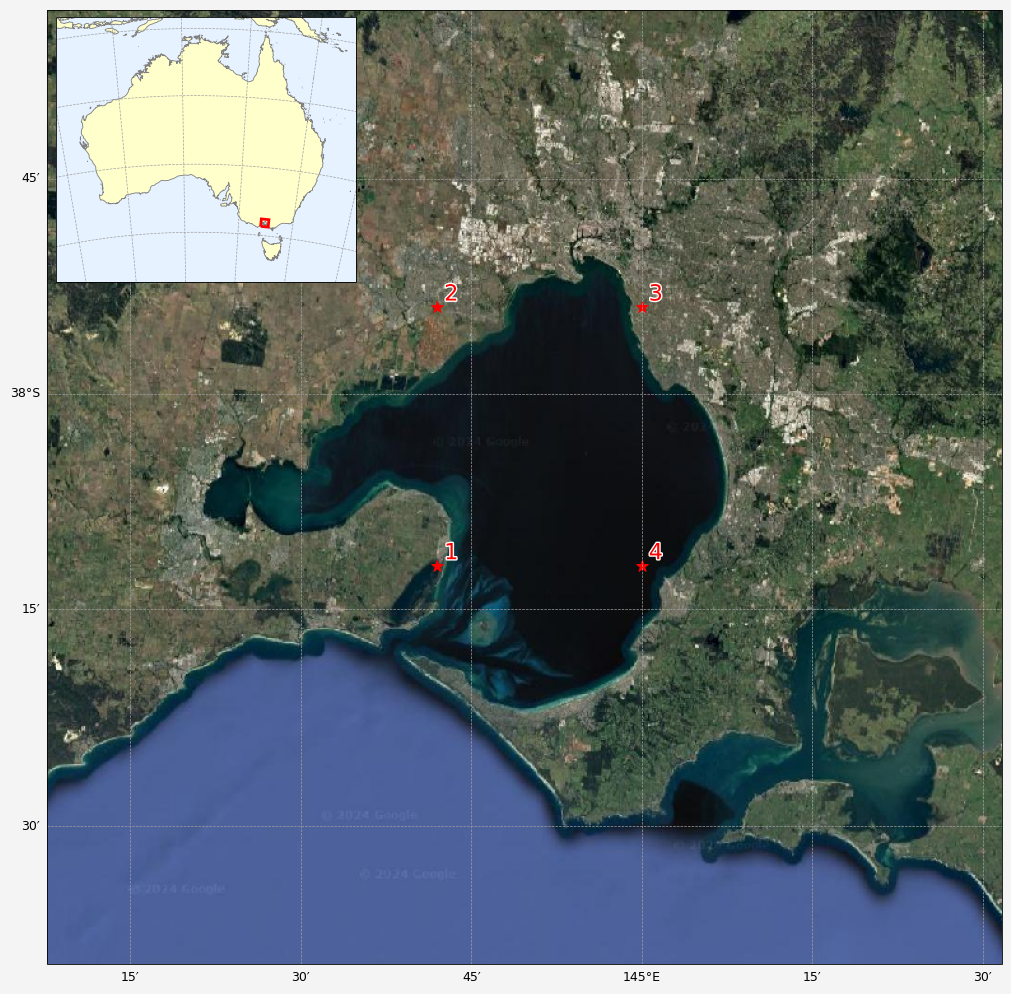

In [1]:
import cartopy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.io.img_tiles as cimgt
import matplotlib.patheffects as pe
import matplotlib.path as mpath
import matplotlib.patches as mpatch

# load satellite tile handler
image = cimgt.GoogleTiles(style='satellite')
# set the figure up - plotting in standard Mercator (EPSG:3857)
f, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection=cartopy.crs.Mercator()), layout='constrained')
# example of set_extent in another projection MGA_Z55
ax.set_extent((250000, 370000, 5720000, 5840000), crs=cartopy.crs.epsg(28355))
ax.add_image(image, 10)

# dataframe for our points
df = pd.DataFrame({'id': np.array([1, 2, 3, 4]),
                   'lon': np.array([144.7, 144.7, 145, 145]),
                   'lat': np.array([-38.2, -37.9, -37.9, -38.2])
                  })

ax.scatter(df.lon, df.lat, marker='*', c='r', s=80, transform=cartopy.crs.PlateCarree(), zorder=2)
for _, item in df.iterrows():
    # example of point annotation, including some neat path_effects stuff to provide the white halo
    ax.annotate(int(item.id), xy=(item.lon, item.lat), xytext=(5, 5), textcoords='offset points', xycoords=cartopy.crs.PlateCarree(), 
                c='r', size=16, path_effects=[pe.withStroke(linewidth=2, foreground='white')])
ax.gridlines(lw=0.5, ls='--', color='#a0a0a0', draw_labels=['left', 'bottom'], dms=True,
             xlocs=np.arange(7)*0.25+144, ylocs=np.arange(6)*0.25-38.5, transform=cartopy.crs.PlateCarree())

aus_albers = cartopy.crs.AlbersEqualArea(
    central_longitude=132,
    standard_parallels=[-18, -36],
    globe=cartopy.crs.Globe(ellipse='GRS80')
)

# subset axis
ax1 = f.add_axes([0.05, 0.705, 0.30, 0.27], projection=aus_albers)
ax1.set_facecolor('#e6f2ff')
ax1.set_extent((112, 155, -46, -8), crs=cartopy.crs.PlateCarree())
ax1.gridlines(lw=0.5, ls='--', color='#a0a0a0', ylocs=np.arange(-80, 0, 10))
ax1.add_feature(cartopy.feature.NaturalEarthFeature(category='physical', name='land', scale='10m',
                                                   facecolor='#ffffcc', edgecolor='#808080', zorder=0))
# grab the main axis bounds to set the boundary on the inset axis
ax_bnds = ax.get_extent()
map_border = mpath.Path([(ax_bnds[0], ax_bnds[2]), (ax_bnds[0], ax_bnds[3]), (ax_bnds[1], ax_bnds[3]), (ax_bnds[1], ax_bnds[2]), (ax_bnds[0], ax_bnds[2])])
ax1.add_patch(mpatch.PathPatch(map_border, fc='none', ec='r', lw=2, transform=cartopy.crs.Mercator()))